<h1>Daniel Chang</h1>
<h1>C&S BIO 100 Final Project Code</h1>

In [1]:
# to help when converting html to PDF

from IPython.display import HTML
HTML("""
<style>
pre {
    white-space: pre-wrap;
    word-wrap: break-word;
}
</style>
""")

In [8]:
# importing packages 
# uploading data set

import pandas as pd
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.model_selection import KFold
from sklearn.utils import resample

import matplotlib.pyplot as plt

df = pd.read_csv("GTEx_Analysis_Filtered_TPM_with_pheno.csv")


In [ ]:
# keeping columns that are meta data
meta_cols = ['SAMPID', 'SMTSD', 'SUBJID', 'AGE', 'SEX', 'AGE_NUM', 'SEX_LABEL']

# keeping only the numeric columns``
numeric_df = df.select_dtypes(include=['number'])

cols_to_drop = []

# for col in meta_cols:
#     if col in numeric_df.columns:
#         cols_to_drop.append(col)

x_genes = numeric_df.drop(columns = cols_to_drop)

# remove metadata numeric columns (like AGE_NUM, SEX) from the gene matrix
X_genes = numeric_df.drop(columns=[col for col in meta_cols if col in numeric_df.columns])

y_age = df['AGE_NUM']           # numeric age
age_group = df['AGE']           # categorical age group (if you use classification)
tissue = df['SMTSD']            # tissue label
sex = df['SEX']                 # usually 1/2 in GTEx; if not, adjust

print("X_genes shape:", X_genes.shape)
print("Example columns:", X_genes.columns[:5])

print(df.head())

X_genes shape: (2153, 26611)
Example columns: Index(['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1'], dtype='str')
                     SAMPID      A1BG  A1BG-AS1      A1CF       A2M   A2M-AS1  \
0  GTEX-1117F-0005-SM-HL9SH  0.853094  0.328672  0.419755  1.133688  0.067703   
1  GTEX-1117F-0426-SM-5EGHI  0.771527  0.247271  0.058746  6.798375  1.244437   
2  GTEX-1117F-3226-SM-5N9CT  2.269632  1.627032  0.009723  4.142479  1.499762   
3  GTEX-111CU-0005-SM-GJ3PH  2.304628  1.814596  0.000000  0.123619  0.100465   
4  GTEX-111CU-2026-SM-5GZZC  0.231301  0.377255  0.016495  5.382273  1.088684   

      A2ML1     A2MP1   A3GALT2    A4GALT  ...    ZYG11B       ZYX     ZZEF1  \
0  0.021484  0.033800  0.000000  0.124156  ...  1.066909  7.746225  1.290472   
1  1.589730  0.157665  0.209271  2.742295  ...  4.337697  6.346503  4.860700   
2  1.076087  0.163819  0.094547  2.288196  ...  2.903850  7.142577  3.594764   
3  0.000000  0.000000  1.834015  0.056541  ...  2.564266  9.978038  3.722925   


In [3]:
print(tissue)

0             Whole Blood
1       Muscle - Skeletal
2          Brain - Cortex
3             Whole Blood
4       Muscle - Skeletal
              ...        
2148    Muscle - Skeletal
2149       Brain - Cortex
2150          Whole Blood
2151                Liver
2152    Muscle - Skeletal
Name: SMTSD, Length: 2153, dtype: str


In [4]:
# scaling 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_genes)

print("Scaled matrix shape:", X_scaled.shape)

Scaled matrix shape: (2153, 26611)


          PC1         PC2         PC3        PC4        PC5        PC6  \
0 -138.758504  -84.345135 -136.637298 -79.785116 -19.496152  17.209604   
1   65.527761  -45.162617   52.762914   6.038043 -11.556401   5.160620   
2  107.678495  113.441354  -56.231216 -46.848939  -1.231245  -1.945236   
3 -113.112787   35.418728   29.802362 -13.126197  72.747065   8.414359   
4   63.911979  -55.272990   47.123074  -0.437581   6.854206 -33.671728   

         PC7        PC8        PC9       PC10  AGE_NUM AGE_GROUP  \
0  16.065754 -25.621786   0.924183 -27.494900       65     60-69   
1  -2.943638 -51.834504   0.634172 -11.065597       65     60-69   
2 -21.955197 -17.156502 -15.093587  -6.714166       65     60-69   
3   2.872857  -4.190199  -6.493306   3.428233       55     50-59   
4  18.129218   6.525776 -10.301066  -5.063487       55     50-59   

              TISSUE  SEX  
0        Whole Blood    2  
1  Muscle - Skeletal    2  
2     Brain - Cortex    2  
3        Whole Blood    1  
4  Mus

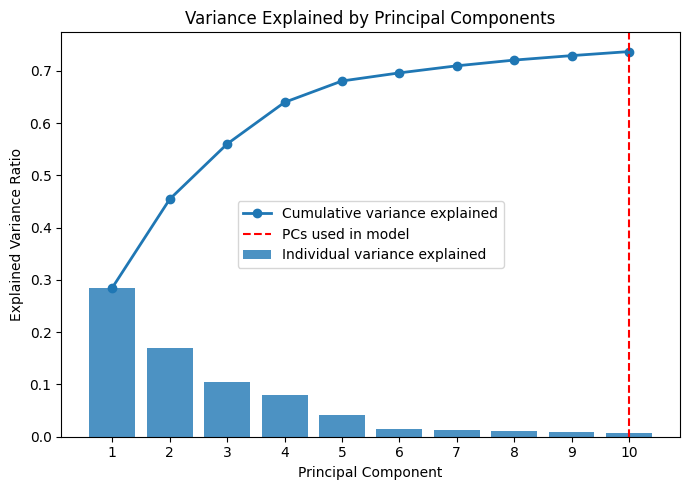

PC1: 28.52% | cumulative 28.52%
PC2: 16.93% | cumulative 45.45%
PC3: 10.56% | cumulative 56.01%
PC4: 7.96% | cumulative 63.97%
PC5: 4.08% | cumulative 68.05%
PC6: 1.55% | cumulative 69.61%
PC7: 1.35% | cumulative 70.96%
PC8: 1.10% | cumulative 72.05%
PC9: 0.85% | cumulative 72.91%
PC10: 0.77% | cumulative 73.68%


In [ ]:
# fit PCA keeping first 10 components
n_pcs = 10
pca = PCA(n_components=n_pcs)
X_pcs = pca.fit_transform(X_scaled)

# put PCs + metadata in one dataframe for plotting/modeling
pc_cols = [f"PC{i+1}" for i in range(n_pcs)]
pcs_df = pd.DataFrame(X_pcs, columns=pc_cols)

pcs_df['AGE_NUM'] = y_age.values
pcs_df['AGE_GROUP'] = age_group.values
pcs_df['TISSUE'] = tissue.values
pcs_df['SEX'] = sex.values

print(pcs_df.head())

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)
pcs = np.arange(1, len(explained_var) + 1)

plt.figure(figsize=(7,5))
plt.bar(pcs, explained_var, alpha=0.8, label="Individual variance explained")
plt.plot(pcs, cum_var, marker='o', linewidth=2, label="Cumulative variance explained")
plt.axvline(10, linestyle='--', color='red', label='PCs used in model')

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Variance Explained by Principal Components")
plt.xticks(pcs)
plt.legend()
plt.tight_layout()
plt.show()

# printing out the variances explained from each PC from 1-10

for i in range(len(pca.explained_variance_ratio_)):
    print(f"PC{i+1}: {pca.explained_variance_ratio_[i]*100:.2f}% | cumulative {cum_var[i]*100:.2f}%")

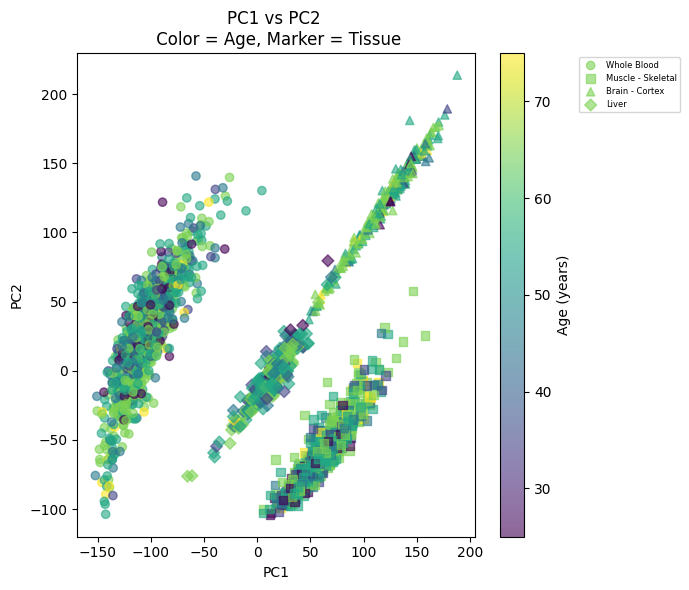

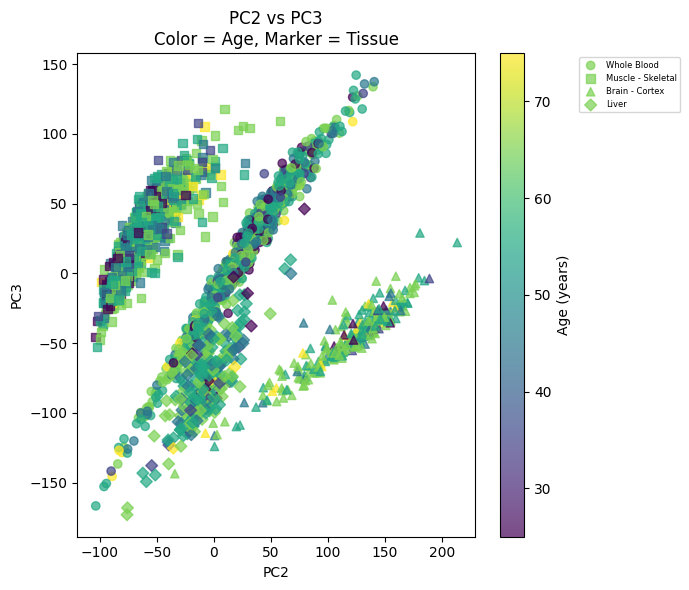

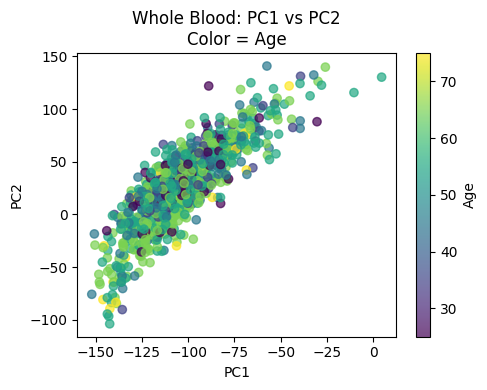

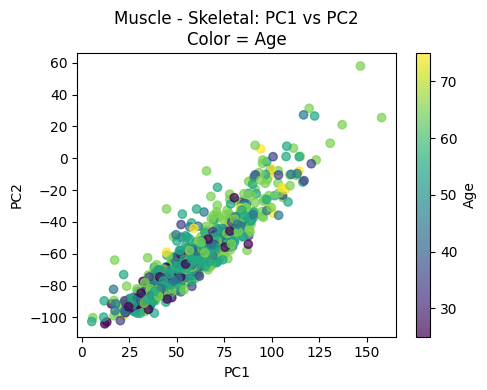

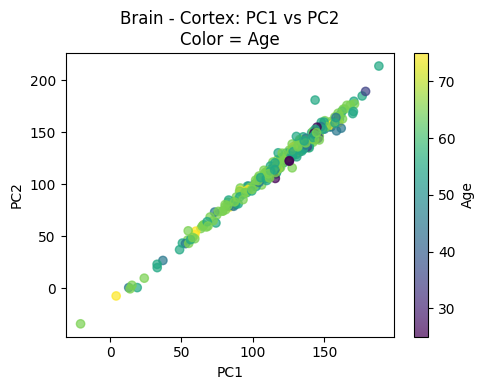

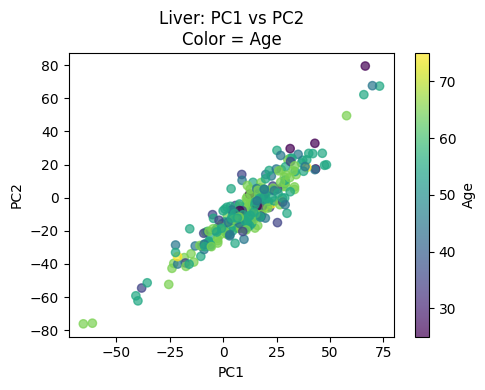

In [ ]:
plt.figure(figsize=(7, 6))

# mapping the 4 tissues to makers
tissues_unique = pcs_df['TISSUE'].unique()
marker_map = {t: m for t, m in zip(tissues_unique, ['o', 's', '^', 'D', 'P', 'X', '*'] * 5)}

# PC1 vs PC2 all tissues

for tiss in tissues_unique:
    subset = pcs_df[pcs_df['TISSUE'] == tiss]
    plt.scatter(
        subset['PC1'], subset['PC2'],
        c=subset['AGE_NUM'],            # continuous color by age
        cmap='viridis',
        marker=marker_map[tiss],
        alpha=0.6,
        label=tiss
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 \n Color = Age, Marker = Tissue")
plt.colorbar(label="Age (years)")
plt.legend(bbox_to_anchor=(1.25, 1), loc='upper left', fontsize=6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))

# PC2 vs PC3 all tissues

for tiss in tissues_unique:
    subset = pcs_df[pcs_df['TISSUE'] == tiss]
    plt.scatter(
        subset['PC2'],
        subset['PC3'],
        c=subset['AGE_NUM'],
        cmap='viridis',
        marker=marker_map[tiss],
        alpha=0.7,
        label=tiss
    )

plt.xlabel("PC2")
plt.ylabel("PC3")
plt.title("PC2 vs PC3\nColor = Age, Marker = Tissue")
plt.colorbar(label="Age (years)")
plt.legend(bbox_to_anchor=(1.25, 1), loc='upper left', fontsize=6)
plt.tight_layout()
plt.show()

# PC1 vs PC2 Whole Blood
# PC1 vs PC2 Muscle Skeletal 
# PC1 vs PC2 Brain - Cortex
# PC1 vs PC2 Liver

for tiss in pcs_df['TISSUE'].unique():
    subset = pcs_df[pcs_df['TISSUE'] == tiss]
    
    plt.figure(figsize=(5,4))
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        c=subset['AGE_NUM'],
        cmap='viridis',
        alpha=0.7
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"{tiss}: PC1 vs PC2\nColor = Age")
    plt.colorbar(label="Age")
    plt.tight_layout()
    plt.show()

In [ ]:
# 10 PCs to use in the model
k_pcs = 10
X_model = pcs_df[[f"PC{i+1}" for i in range(k_pcs)]].copy()

# adding sex as covariate in the x (numerical) model 
X_model['SEX'] = pcs_df['SEX'].values  #

y = pcs_df['AGE_NUM'].values

print("X_model shape:", X_model.shape)

X_model shape: (2153, 11)


In [ ]:
# linear regression model 
# k fold 5
def cv_performance_r2_rmse(model, X, y, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    r2_scores = []
    rmse_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # R^2 scores -> variance explaioned
        ss_res = np.sum((y_test - y_pred) ** 2)     
        ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
        r2 = 1 - ss_res / ss_tot

        # RMSSE scores -> age prediction error 
        rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

        r2_scores.append(r2)
        rmse_scores.append(rmse)

    return np.mean(r2_scores), np.mean(rmse_scores)

In [27]:
linreg = LinearRegression()
mean_r2, mean_rmse = cv_performance_r2_rmse(linreg, X_model.values, y, n_splits=5)
print("Baseline linear regression CV R^2:", mean_r2)
print("Baseline linear regression CV RMSE:", mean_rmse)

Baseline linear regression CV R^2: 0.12930693433966992
Baseline linear regression CV RMSE: 11.694935614806713


In [ ]:
# bootstrap function 

def bootstrap_cv_r2(model, X, y, n_boot=10000, n_splits=5, random_state=42):
    rng = np.random.default_rng(random_state)
    r2_boot = []

    n_samples = X.shape[0]

    for b in range(n_boot):
        # sample indices with replacement
        boot_idx = rng.integers(0, n_samples, size=n_samples)
        X_boot = X[boot_idx]
        y_boot = y[boot_idx]

        r2_mean, _ = cv_performance_r2_rmse(model, X_boot, y_boot,
                                            n_splits=n_splits,
                                            random_state= random_state + b)
        r2_boot.append(r2_mean)

    r2_boot = np.array(r2_boot)
    ci_lower = np.percentile(r2_boot, 2.5)
    ci_upper = np.percentile(r2_boot, 97.5)

    return r2_boot, ci_lower, ci_upper

In [ ]:
# running the linear regression model

linreg = LinearRegression()
r2_boot_all, ci_low_all, ci_high_all = bootstrap_cv_r2(
    linreg, X_model.values, y, n_boot=10000, n_splits=5
)

print("All tissues: R^2 bootstrap mean:", np.mean(r2_boot_all))
print("95% CI:", (ci_low_all, ci_high_all))

All tissues: R^2 bootstrap mean: 0.12973442337477803
95% CI: (0.10190833500874232, 0.15959533496969483)


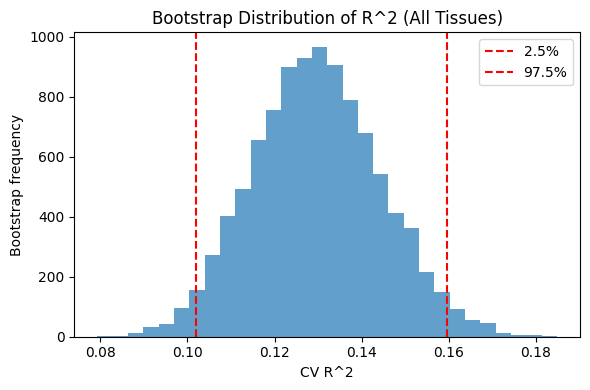

In [ ]:
# confidence interval graph for all tissues

plt.figure(figsize=(6,4))
plt.hist(r2_boot_all, bins=30, alpha=0.7)
plt.axvline(ci_low_all, color='red', linestyle='--', label='2.5%')
plt.axvline(ci_high_all, color='red', linestyle='--', label='97.5%')
plt.xlabel("CV R^2")
plt.ylabel("Bootstrap frequency")
plt.title("Bootstrap Distribution of R^2 (All Tissues)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# specifci tissue bootstrap analysis

results = []

unique_tissues = pcs_df['TISSUE'].unique()

for tiss in unique_tissues:
    mask = pcs_df['TISSUE'] == tiss
    X_tiss = X_model.values[mask]
    y_tiss = y[mask]

    # Skip tiny tissues
    if X_tiss.shape[0] < 40:
        continue

    linreg = LinearRegression()
    r2_boot_tiss, ci_low, ci_high = bootstrap_cv_r2(
        linreg, X_tiss, y_tiss, n_boot=10000, n_splits=5
    )

    results.append({
        'TISSUE': tiss,
        'n_samples': X_tiss.shape[0],
        'R2_mean': np.mean(r2_boot_tiss),
        'R2_CI_low': ci_low,
        'R2_CI_high': ci_high
    })

results_df = pd.DataFrame(results).sort_values('R2_mean', ascending=False)
results_df.head()

,TISSUE,n_samples,R2_mean,R2_CI_low,R2_CI_high
0,Whole Blood,803,0.169510,0.117830,0.223098
1,Muscle - Skeletal,818,0.138641,0.092123,0.186329
3,Liver,262,0.090792,-0.026673,0.212260
2,Brain - Cortex,270,0.048996,-0.067168,0.156553


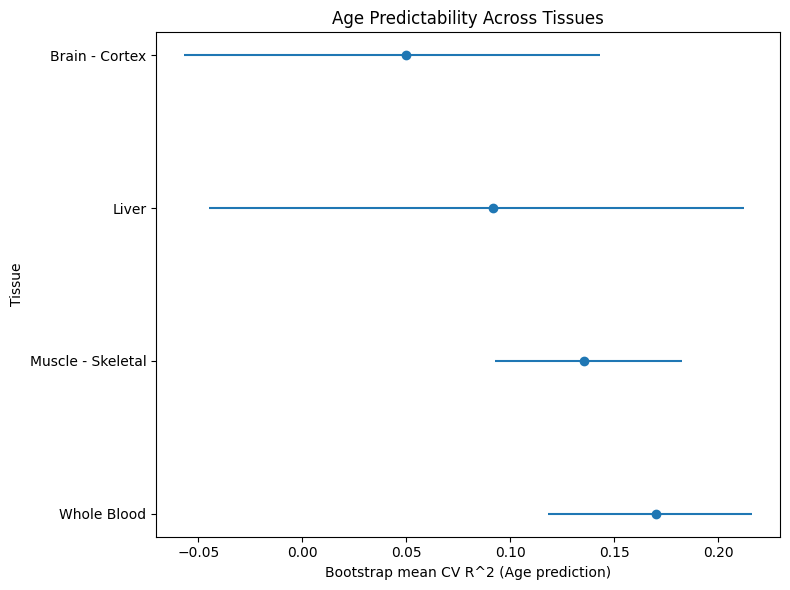

In [ ]:
# specific tissue confidence interval plots

plt.figure(figsize=(8,6))
plt.errorbar(
    results_df['R2_mean'],
    results_df['TISSUE'],
    xerr=[results_df['R2_mean'] - results_df['R2_CI_low'],
          results_df['R2_CI_high'] - results_df['R2_mean']],
    fmt='o'
)
plt.xlabel("Bootstrap mean CV R^2 (Age prediction)")
plt.ylabel("Tissue")
plt.title("Age Predictability Across Tissues")
plt.tight_layout()
plt.show()

<h1>BONUS</h1>

In [ ]:
# Elastic Net analysis 
# 10,000 iterations 

enet = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)

r2_boot_enet, ci_low_enet, ci_high_enet = bootstrap_cv_r2(
    enet, X_model.values, y, n_boot=10000, n_splits=5
)

print("Elastic Net R^2 mean:", np.mean(r2_boot_enet))
print("95% CI:", (ci_low_enet, ci_high_enet))

Elastic Net R^2 mean: 0.13009925910077672
95% CI: (0.10233662799431947, 0.1599442186362225)
